<a href="https://colab.research.google.com/github/simonolocco/Olocco_Simon_ANT2026/blob/main/perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape de X: (100, 2)
Clases únicas: [0 1]


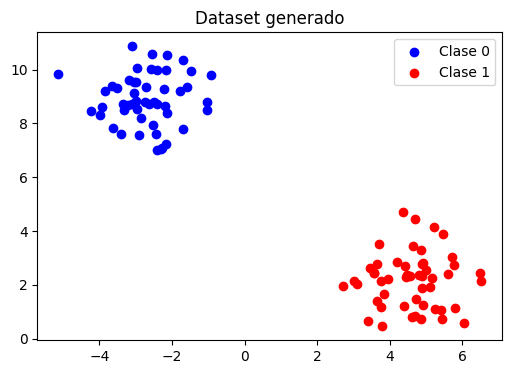

In [1]:
# Bloque 1: Imports y dataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generar datos linealmente separables
X, y = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=1.0)

# Convertir etiquetas de {0,1} a {0,1} — ya está bien para el perceptrón
print("Shape de X:", X.shape)
print("Clases únicas:", np.unique(y))

# Visualizar
plt.figure(figsize=(6,4))
plt.scatter(X[y==0, 0], X[y==0, 1], color='blue', label='Clase 0')
plt.scatter(X[y==1, 0], X[y==1, 1], color='red', label='Clase 1')
plt.title("Dataset generado")
plt.legend()
plt.show()

In [3]:
# Bloque 2: Clase Perceptrón
class Perceptron:
    def __init__(self, learning_rate=0.1, n_epochs=50):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.bias = None

    def activation(self, z):
        # Función escalón: devuelve 1 si z >= 0, sino 0
        return np.where(z >= 0, 1, 0)

    def predict(self, X):
        # Forward pass: X · w + b → activación
        z = np.dot(X, self.weights) + self.bias
        return self.activation(z)

    def train(self, X, y):
        n_samples, n_features = X.shape

        # Inicializar pesos aleatorios pequeños y bias en 0
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0

        self.error_history = []  # Para graficar después

        for epoch in range(self.n_epochs):
            errors = 0
            for xi, yi in zip(X, y):
                prediction = self.predict(xi)
                error = yi - prediction

                # Regla del perceptrón: w = w + lr * error * x
                self.weights += self.lr * error * xi
                self.bias    += self.lr * error

                errors += int(error != 0)

            self.error_history.append(errors)
            print(f"Época {epoch+1:3d} | Errores: {errors}")

            if errors == 0:
                print(f"\n✅ Convergió en la época {epoch+1}")
                break

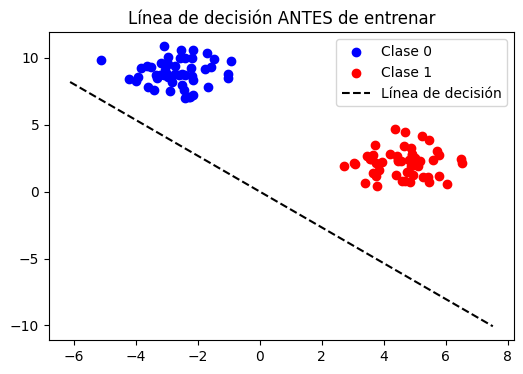

=== Entrenando ===

Época   1 | Errores: 2
Época   2 | Errores: 0

✅ Convergió en la época 2


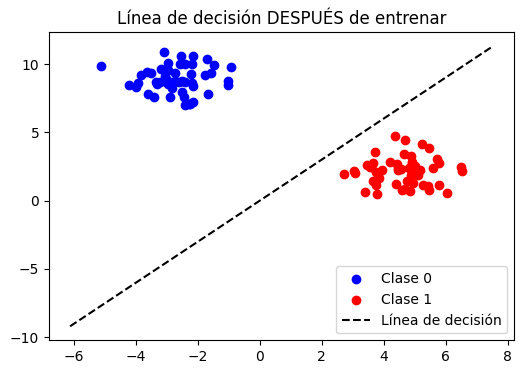

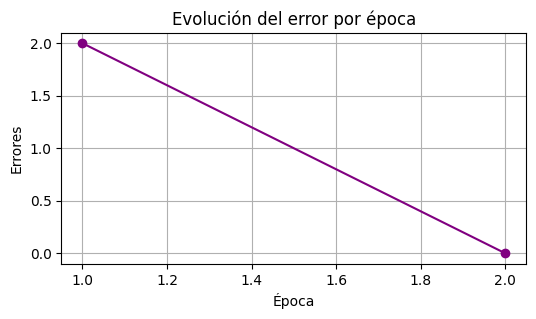

In [4]:
# Bloque 3: Entrenar y graficar

def plot_decision_boundary(X, y, perceptron, title):
    plt.figure(figsize=(6,4))
    plt.scatter(X[y==0, 0], X[y==0, 1], color='blue', label='Clase 0')
    plt.scatter(X[y==1, 0], X[y==1, 1], color='red', label='Clase 1')

    # La línea de decisión es donde w1*x1 + w2*x2 + b = 0
    # Despejando x2: x2 = -(w1*x1 + b) / w2
    x1_vals = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
    x2_vals = -(perceptron.weights[0] * x1_vals + perceptron.bias) / perceptron.weights[1]

    plt.plot(x1_vals, x2_vals, 'k--', label='Línea de decisión')
    plt.title(title)
    plt.legend()
    plt.show()


# --- Crear el perceptrón y graficar ANTES de entrenar ---
p = Perceptron(learning_rate=0.1, n_epochs=50)

# Inicializar pesos manualmente para poder graficar antes
p.weights = np.random.randn(2) * 0.01
p.bias = 0

plot_decision_boundary(X, y, p, "Línea de decisión ANTES de entrenar")

# --- Entrenar ---
print("=== Entrenando ===\n")
p.train(X, y)

# --- Graficar DESPUÉS de entrenar ---
plot_decision_boundary(X, y, p, "Línea de decisión DESPUÉS de entrenar")

# --- Curva de error por época ---
plt.figure(figsize=(6,3))
plt.plot(range(1, len(p.error_history)+1), p.error_history, marker='o', color='purple')
plt.xlabel("Época")
plt.ylabel("Errores")
plt.title("Evolución del error por época")
plt.grid(True)
plt.show()

=== Entrenando con datos NO separables ===

Época   1 | Errores: 14
Época   2 | Errores: 13
Época   3 | Errores: 11
Época   4 | Errores: 11
Época   5 | Errores: 10
Época   6 | Errores: 11
Época   7 | Errores: 13
Época   8 | Errores: 9
Época   9 | Errores: 10
Época  10 | Errores: 12
Época  11 | Errores: 8
Época  12 | Errores: 7
Época  13 | Errores: 13
Época  14 | Errores: 7
Época  15 | Errores: 11
Época  16 | Errores: 10
Época  17 | Errores: 10
Época  18 | Errores: 8
Época  19 | Errores: 9
Época  20 | Errores: 6
Época  21 | Errores: 11
Época  22 | Errores: 6
Época  23 | Errores: 11
Época  24 | Errores: 8
Época  25 | Errores: 9
Época  26 | Errores: 6
Época  27 | Errores: 11
Época  28 | Errores: 6
Época  29 | Errores: 11
Época  30 | Errores: 6
Época  31 | Errores: 11
Época  32 | Errores: 6
Época  33 | Errores: 11
Época  34 | Errores: 6
Época  35 | Errores: 11
Época  36 | Errores: 6
Época  37 | Errores: 11
Época  38 | Errores: 8
Época  39 | Errores: 11
Época  40 | Errores: 8
Época  41 | Er

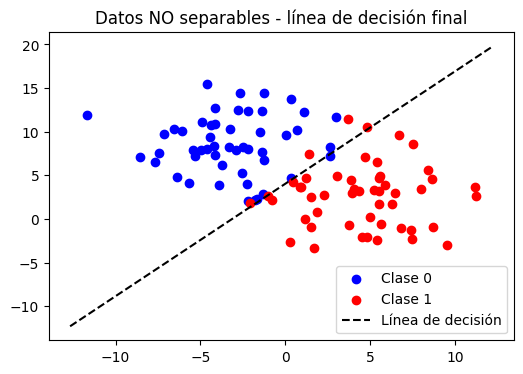

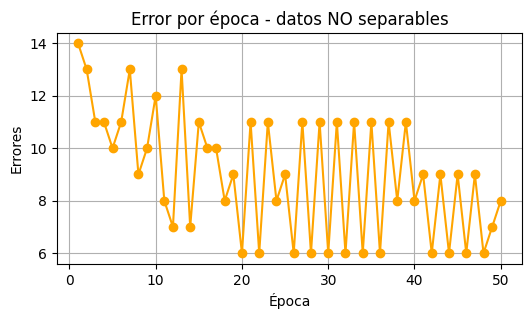

In [5]:
# Bloque 4: Experimento con datos no separables

# Generamos datos que se mezclan (cluster_std grande)
X_ns, y_ns = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=3.5)

print("=== Entrenando con datos NO separables ===\n")
p_ns = Perceptron(learning_rate=0.1, n_epochs=50)
p_ns.train(X_ns, y_ns)

# Gráfico final con la línea de decisión
plot_decision_boundary(X_ns, y_ns, p_ns, "Datos NO separables - línea de decisión final")

# Curva de error
plt.figure(figsize=(6,3))
plt.plot(range(1, len(p_ns.error_history)+1), p_ns.error_history, marker='o', color='orange')
plt.xlabel("Época")
plt.ylabel("Errores")
plt.title("Error por época - datos NO separables")
plt.grid(True)
plt.show()

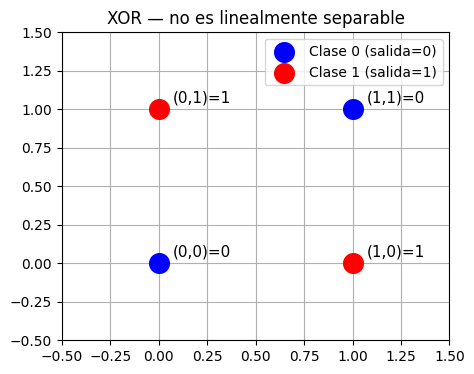

=== Intentando entrenar XOR ===

Época   1 | Errores: 4
Época   2 | Errores: 4
Época   3 | Errores: 4
Época   4 | Errores: 4
Época   5 | Errores: 4
Época   6 | Errores: 4
Época   7 | Errores: 4
Época   8 | Errores: 4
Época   9 | Errores: 4
Época  10 | Errores: 4
Época  11 | Errores: 4
Época  12 | Errores: 4
Época  13 | Errores: 4
Época  14 | Errores: 4
Época  15 | Errores: 4
Época  16 | Errores: 4
Época  17 | Errores: 4
Época  18 | Errores: 4
Época  19 | Errores: 4
Época  20 | Errores: 4
Época  21 | Errores: 4
Época  22 | Errores: 4
Época  23 | Errores: 4
Época  24 | Errores: 4
Época  25 | Errores: 4
Época  26 | Errores: 4
Época  27 | Errores: 4
Época  28 | Errores: 4
Época  29 | Errores: 4
Época  30 | Errores: 4
Época  31 | Errores: 4
Época  32 | Errores: 4
Época  33 | Errores: 4
Época  34 | Errores: 4
Época  35 | Errores: 4
Época  36 | Errores: 4
Época  37 | Errores: 4
Época  38 | Errores: 4
Época  39 | Errores: 4
Época  40 | Errores: 4
Época  41 | Errores: 4
Época  42 | Errores: 4
É

In [6]:
# Pregunta 1: Visualizar XOR
X_xor = np.array([[0,0], [0,1], [1,0], [1,1]])
y_xor = np.array([0, 1, 1, 0])  # XOR

plt.figure(figsize=(5,4))
plt.scatter(X_xor[y_xor==0, 0], X_xor[y_xor==0, 1],
            color='blue', s=200, zorder=5, label='Clase 0 (salida=0)')
plt.scatter(X_xor[y_xor==1, 0], X_xor[y_xor==1, 1],
            color='red', s=200, zorder=5, label='Clase 1 (salida=1)')

# Anotar cada punto
for i, (x, label) in enumerate(zip(X_xor, y_xor)):
    plt.annotate(f'({x[0]},{x[1]})={label}', xy=x,
                  textcoords="offset points", xytext=(10,5), fontsize=11)

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.title("XOR — no es linealmente separable")
plt.legend()
plt.grid(True)
plt.show()

# Intentar entrenar igual
print("=== Intentando entrenar XOR ===\n")
p_xor = Perceptron(learning_rate=0.1, n_epochs=50)
p_xor.train(X_xor, y_xor)


¿Por qué el perceptrón no puede resolver XOR?
El perceptrón solo puede trazar una línea recta para separar clases. XOR tiene sus puntos positivos en (0,1) y (1,0), y los negativos en (0,0) y (1,1) — es imposible separarlos con una sola línea. No importa cómo la ubiques, siempre va a clasificar mal al menos 2 puntos. Para resolver XOR se necesita una red neuronal con al menos una capa oculta.

Época   1 | Errores: 4
Época   2 | Errores: 0

✅ Convergió en la época 2
Época   1 | Errores: 0

✅ Convergió en la época 1
Época   1 | Errores: 2
Época   2 | Errores: 0

✅ Convergió en la época 2


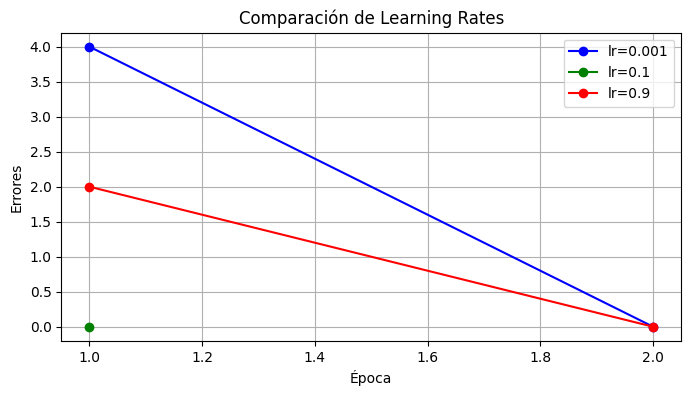

In [7]:
# Pregunta 2: Comparar learning rates
learning_rates = [0.001, 0.1, 0.9]
colores = ['blue', 'green', 'red']

plt.figure(figsize=(8,4))

for lr, color in zip(learning_rates, colores):
    p_lr = Perceptron(learning_rate=lr, n_epochs=50)
    p_lr.train(X, y)
    plt.plot(range(1, len(p_lr.error_history)+1),
             p_lr.error_history,
             marker='o', color=color, label=f'lr={lr}')

plt.xlabel("Época")
plt.ylabel("Errores")
plt.title("Comparación de Learning Rates")
plt.legend()
plt.grid(True)
plt.show()

¿Qué pasa si cambiamos el learning rate?

lr muy pequeño (0.001): los pesos se ajustan muy poco por vez, puede tardar más épocas en converger.
lr medio (0.1): balance ideal, converge rápido y estable.
lr muy grande (0.9): los pasos son tan grandes que puede "saltear" la solución y oscilar, aunque con datos muy separados igual converge.
En datos más complejos, un lr muy alto puede hacer que el error oscile y nunca converja.

Época   1 | Errores: 0

✅ Convergió en la época 1
std=1.0 → épocas hasta converger o parar: 1

Época   1 | Errores: 3
Época   2 | Errores: 0

✅ Convergió en la época 2
std=2.0 → épocas hasta converger o parar: 2

Época   1 | Errores: 9
Época   2 | Errores: 10
Época   3 | Errores: 7
Época   4 | Errores: 8
Época   5 | Errores: 9
Época   6 | Errores: 6
Época   7 | Errores: 6
Época   8 | Errores: 6
Época   9 | Errores: 6
Época  10 | Errores: 6
Época  11 | Errores: 4
Época  12 | Errores: 6
Época  13 | Errores: 3
Época  14 | Errores: 1
Época  15 | Errores: 3
Época  16 | Errores: 1
Época  17 | Errores: 5
Época  18 | Errores: 5
Época  19 | Errores: 5
Época  20 | Errores: 5
Época  21 | Errores: 5
Época  22 | Errores: 0

✅ Convergió en la época 22
std=3.0 → épocas hasta converger o parar: 22



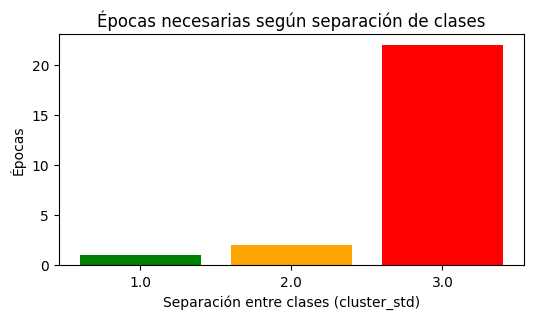

In [8]:
# Pregunta 3: ¿De qué depende la convergencia?

# Probar con distintos cluster_std para ver cómo afecta las épocas
separaciones = [1.0, 2.0, 3.0]
epocas_necesarias = []

for std in separaciones:
    X_test, y_test = make_blobs(n_samples=100, centers=2,
                                 random_state=42, cluster_std=std)
    p_test = Perceptron(learning_rate=0.1, n_epochs=100)
    p_test.train(X_test, y_test)
    epocas_necesarias.append(len(p_test.error_history))
    print(f"std={std} → épocas hasta converger o parar: {len(p_test.error_history)}\n")

plt.figure(figsize=(6,3))
plt.bar([str(s) for s in separaciones], epocas_necesarias, color=['green','orange','red'])
plt.xlabel("Separación entre clases (cluster_std)")
plt.ylabel("Épocas")
plt.title("Épocas necesarias según separación de clases")
plt.show()

¿Cuántas épocas necesitó para converger? ¿De qué depende?

std=1.0 → 1 época: clases muy separadas, casi cualquier línea las divide
std=2.0 → 2 épocas: algo de superposición, necesita un ajuste
std=3.0 → 22 épocas: las nubes se mezclan bastante, el perceptrón tiene que hacer muchas correcciones

La convergencia depende principalmente de qué tan separables son los datos. También influyen el learning rate y la inicialización aleatoria de los pesos. El perceptrón siempre converge si los datos son linealmente separables — esto está garantizado por el Teorema de Convergencia del Perceptrón. Si no lo son, nunca converge.